# Notebook 05 — Diagnostic Checks on the Pre-Trained Encoder

Two quick sanity checks requested before pursuing wider horizons (i.e. before
extending pretraining/fine-tuning to larger prediction offsets or scaling beyond
Subject 1). Both use **Subject 1 only**, for speed, and the existing
`ahpc_k1_pretrained_best.pt` encoder (frozen — no gradients flow into it here).

1. **Cosine similarity: adjacent vs. random pairs** — does the encoder's embedding
   space actually reflect temporal/trial structure? Embeddings of consecutive
   segments from the same trial should be more similar than embeddings of segments
   drawn from unrelated trials, if the encoder is capturing anything beyond noise.
2. **Linear probe MSE vs. k** — how well does a simple linear map predict the
   embedding k steps ahead, for k = 1 .. 25? This is a direct probe of how quickly
   predictability decays with horizon, which bears on whether pretraining with
   larger horizons is likely to be useful.

Both checks load the encoder once, freeze it completely, and only ever call it
under `torch.no_grad()`.

In [1]:
import os
import copy
import pickle
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

DATA_PATH = "/workspaces/AH-PC/src/data/processed/subject_01_pairs.pkl"
CKPT_PATH = "/workspaces/AH-PC/src/models/ahpc_k1_pretrained_best.pt"
NOTEBOOK_DIR = "/workspaces/AH-PC/src/notebooks"

COSINE_PLOT_PATH = os.path.join(NOTEBOOK_DIR, "diagnostic_cosine_similarity.png")
COSINE_PLOT_CENTERED_PATH = os.path.join(NOTEBOOK_DIR, "diagnostic_cosine_similarity_centered.png")
MSE_PLOT_PATH = os.path.join(NOTEBOOK_DIR, "diagnostic_linear_probe_mse.png")

# Dataviz reference palette (skill: dataviz) — categorical slots 1 (blue) & 2 (aqua)
COLOR_BLUE = "#2a78d6"
COLOR_AQUA = "#1baf7a"
COLOR_TEXT = "#0b0b0b"
COLOR_MUTED = "#52514e"
COLOR_GRID = "#e3e2dd"


PyTorch version: 2.12.1+cu130
Device: cpu


## 1. Re-Defining the AH-PC Encoder

Same `SheibaniEncoder` + raw-feature-space `projector` used throughout Notebooks
02–04e. Only `sheibani_encoder.*` and `projector.*` tensors are restored from the
checkpoint — the `decoder.*` weights present in `ahpc_k1_pretrained_best.pt` are
pretraining-only and unused here.

In [2]:
class BandAttention(nn.Module):
    def __init__(self, num_bands):
        super().__init__()
        self.fc1 = nn.Linear(num_bands * 2, num_bands // 2)
        self.fc2 = nn.Linear(num_bands // 2, num_bands)

    def forward(self, x):  # x: (B, C, num_bands)
        avg_pool = x.mean(dim=1)
        max_pool = x.max(dim=1).values
        context  = torch.cat([avg_pool, max_pool], dim=-1)
        weights  = torch.sigmoid(self.fc2(F.relu(self.fc1(context))))
        return x * weights.unsqueeze(1)


class ChannelAttention(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        self.fc1 = nn.Linear(num_channels * 2, num_channels // 2)
        self.fc2 = nn.Linear(num_channels // 2, num_channels)

    def forward(self, x):  # x: (B, C, num_bands)
        avg_pool = x.mean(dim=2)
        max_pool = x.max(dim=2).values
        context  = torch.cat([avg_pool, max_pool], dim=-1)
        weights  = torch.sigmoid(self.fc2(F.relu(self.fc1(context))))
        return x * weights.unsqueeze(2)


class SheibaniEncoder(nn.Module):
    """Sheibani's attention + CNN encoder, reproduced exactly (Notebooks 02/03/03b/03c/04c/04d)."""

    OUT_CHANNELS = 64

    def __init__(self):
        super().__init__()
        self.band_attn = BandAttention(num_bands=5)
        self.channel_attn = ChannelAttention(num_channels=62)

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d((2, 1)),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),
        )

        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

    def forward(self, x):  # x: (B, 62, 5)
        x = self.band_attn(x)
        x = self.channel_attn(x)
        x = x.unsqueeze(1)
        x = self.encoder(x)
        x = self.bottleneck(x)
        return x  # (B, 64, 15, 5)


LATENT_DIM      = 256
BOTTLENECK_FLAT = 64 * 15 * 5  # 4800 — flattened (C, H, W) bottleneck


class FrozenEncoder(nn.Module):
    """SheibaniEncoder + projector, loaded from a pretraining checkpoint and
    permanently frozen (eval mode, requires_grad=False on every parameter)."""

    def __init__(self, ckpt_path, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = SheibaniEncoder()
        self.projector = nn.Sequential(
            nn.Flatten(),
            nn.Linear(BOTTLENECK_FLAT, latent_dim),
            nn.LayerNorm(latent_dim),
        )

        ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
        full_sd = ckpt["model_state_dict"]
        enc_sd = {
            k[len("sheibani_encoder."):]: v
            for k, v in full_sd.items() if k.startswith("sheibani_encoder.")
        }
        proj_sd = {
            k[len("projector."):]: v
            for k, v in full_sd.items() if k.startswith("projector.")
        }
        self.encoder.load_state_dict(enc_sd)
        self.projector.load_state_dict(proj_sd)

        for p in self.parameters():
            p.requires_grad = False
        self.eval()

    def train(self, mode: bool = True):
        # Permanently frozen: ignore any .train() calls from outer code.
        return super().train(False)

    @torch.no_grad()
    def forward(self, x):
        feat = self.encoder(x)
        return self.projector(feat)


encoder = FrozenEncoder(CKPT_PATH).to(DEVICE)
n_params = sum(p.numel() for p in encoder.parameters())
n_trainable = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print(f"Loaded frozen encoder from: {CKPT_PATH}")
print(f"Total params: {n_params:,}  |  Trainable params: {n_trainable:,} (must be 0)")
assert n_trainable == 0, "Encoder must be fully frozen for these diagnostics."


Loaded frozen encoder from: /workspaces/AH-PC/src/models/ahpc_k1_pretrained_best.pt
Total params: 1,258,984  |  Trainable params: 0 (must be 0)


## 2. Loading Subject 1's Segments

Each entry in `subject_01_pairs.pkl` is one segment (`anchor`, shape `(62, 5)`)
tagged with its `trial` and `seg_idx` (position within that trial). We group
segments by trial and sort by `seg_idx` to get each trial's segment sequence in
order — this is what both checks need: "segment `i`" and "segment `i+k`" are
positions within one trial's ordered sequence.

In [3]:
with open(DATA_PATH, "rb") as f:
    pairs = pickle.load(f)

print(f"Loaded {len(pairs)} segments for Subject 1 from {DATA_PATH}")

trial_segments = {}  # trial -> list of anchor arrays, ordered by seg_idx
for p in pairs:
    trial_segments.setdefault(p["trial"], []).append((p["seg_idx"], p["anchor"]))

for trial in trial_segments:
    trial_segments[trial].sort(key=lambda t: t[0])
    trial_segments[trial] = [np.asarray(a, dtype=np.float32) for _, a in trial_segments[trial]]

trial_ids = sorted(trial_segments.keys())
lengths = [len(trial_segments[t]) for t in trial_ids]
print(f"Trials: {len(trial_ids)}  |  segments per trial: min={min(lengths)}, "
      f"max={max(lengths)}, mean={np.mean(lengths):.1f}")


Loaded 1463 segments for Subject 1 from /workspaces/AH-PC/src/data/processed/subject_01_pairs.pkl
Trials: 45  |  segments per trial: min=5, max=66, mean=32.5


## 3. Embedding Every Segment Once

The encoder is deterministic and frozen, so each segment's 256-d embedding is
computed exactly once here and cached by `(trial, seg_idx)`. Both checks below
just index into this cache instead of re-running the encoder.

In [4]:
@torch.no_grad()
def embed_batch(segments):
    x = torch.from_numpy(np.stack(segments)).float().to(DEVICE)  # (B, 62, 5)
    z = encoder(x)
    return z.cpu().numpy()


trial_embeddings = {}  # trial -> (n_segments, 256) array, aligned with trial_segments order
for trial in trial_ids:
    trial_embeddings[trial] = embed_batch(trial_segments[trial])

total_embedded = sum(v.shape[0] for v in trial_embeddings.values())
print(f"Embedded {total_embedded} segments across {len(trial_ids)} trials "
      f"(embedding dim = {trial_embeddings[trial_ids[0]].shape[1]}).")


Embedded 1463 segments across 45 trials (embedding dim = 256).


### Mean-Centered Variant (for Check 1)

Check 1 below reports both the raw ("uncentered") cosine similarities above and a
mean-centered variant: the global mean segment (averaged over every segment,
raw feature space, shape `(62, 5)`) is subtracted from each segment *before*
re-embedding. This tests whether the embedding space's apparent structure is
inflated by a shared "DC" component common to all segments (which cosine
similarity is highly sensitive to) rather than genuine trial-to-trial or
temporal variation.

In [5]:
all_segments = np.stack([seg for trial in trial_ids for seg in trial_segments[trial]])
mean_vec = np.mean(all_segments, axis=0)  # shape (62, 5) — global mean segment
print(f"Global mean segment computed from {all_segments.shape[0]} segments, shape = {mean_vec.shape}")

trial_segments_centered = {
    trial: [seg - mean_vec for seg in trial_segments[trial]]
    for trial in trial_ids
}

trial_embeddings_centered = {}  # trial -> (n_segments, 256), embeddings of mean-centered segments
for trial in trial_ids:
    trial_embeddings_centered[trial] = embed_batch(trial_segments_centered[trial])

total_centered = sum(v.shape[0] for v in trial_embeddings_centered.values())
print(f"Re-embedded {total_centered} mean-centered segments across {len(trial_ids)} trials.")


Global mean segment computed from 1463 segments, shape = (62, 5)
Re-embedded 1463 mean-centered segments across 45 trials.


## Check 1 — Cosine Similarity: Adjacent vs. Random Pairs

**What this measures:** for every consecutive pair of segments within the same
trial (`i`, `i+1`), we compute the cosine similarity of their embeddings
("adjacent"). For comparison, we pair each segment `i` with a random segment
drawn from a *different, randomly chosen trial* ("random") and compute the same
similarity. This is computed twice: once on the raw ("uncentered") embeddings,
and once on embeddings of mean-centered segments (global mean segment
subtracted before re-embedding — see above) to check whether a shared
component across all segments is inflating similarity uniformly. The same
adjacent/random pairing (same random draws) is used for both, so the two are
directly comparable.

**What the result means:** if the encoder captures real temporal/EEG structure,
adjacent (same-trial, consecutive) embeddings should be noticeably more similar
than random cross-trial embeddings — consecutive segments overlap in time and
should share signal characteristics, while different trials needn't share
anything. A small or reversed gap would suggest the embedding space is dominated
by something other than temporal continuity (e.g. batch-norm artifacts or
noise). If the gap only appears (or grows) after mean-centering, the uncentered
result was likely masked by a shared "DC" component common to all segments.

In [6]:
rng = np.random.default_rng(SEED)


def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


adjacent_sims, random_sims = [], []
adjacent_sims_centered, random_sims_centered = [], []

for trial in trial_ids:
    embs = trial_embeddings[trial]
    embs_c = trial_embeddings_centered[trial]
    n = embs.shape[0]

    other_trials = [t for t in trial_ids if t != trial]

    for i in range(n - 1):
        # Same random draw used for both centered and uncentered so the two
        # variants are compared on identical pairs.
        rand_trial = other_trials[rng.integers(len(other_trials))]
        rand_idx = rng.integers(trial_embeddings[rand_trial].shape[0])

        adjacent_sims.append(cosine(embs[i], embs[i + 1]))
        random_sims.append(cosine(embs[i], trial_embeddings[rand_trial][rand_idx]))

        adjacent_sims_centered.append(cosine(embs_c[i], embs_c[i + 1]))
        random_sims_centered.append(
            cosine(embs_c[i], trial_embeddings_centered[rand_trial][rand_idx])
        )

adjacent_sims = np.array(adjacent_sims)
random_sims = np.array(random_sims)
adjacent_sims_centered = np.array(adjacent_sims_centered)
random_sims_centered = np.array(random_sims_centered)

adj_mean, adj_std = adjacent_sims.mean(), adjacent_sims.std()
rand_mean, rand_std = random_sims.mean(), random_sims.std()
adj_mean_c, adj_std_c = adjacent_sims_centered.mean(), adjacent_sims_centered.std()
rand_mean_c, rand_std_c = random_sims_centered.mean(), random_sims_centered.std()

print("Uncentered (raw embeddings):")
print(f"  Adjacent pairs (n={len(adjacent_sims)}): mean cosine sim = {adj_mean:.4f}  (std = {adj_std:.4f})")
print(f"  Random pairs   (n={len(random_sims)}): mean cosine sim = {rand_mean:.4f}  (std = {rand_std:.4f})")
print(f"  Gap (adjacent - random): {adj_mean - rand_mean:+.4f}")
print()
print("Mean-centered (global mean segment subtracted before re-embedding):")
print(f"  Adjacent pairs (n={len(adjacent_sims_centered)}): mean cosine sim = {adj_mean_c:.4f}  (std = {adj_std_c:.4f})")
print(f"  Random pairs   (n={len(random_sims_centered)}): mean cosine sim = {rand_mean_c:.4f}  (std = {rand_std_c:.4f})")
print(f"  Gap (adjacent - random): {adj_mean_c - rand_mean_c:+.4f}")


Uncentered (raw embeddings):
  Adjacent pairs (n=1418): mean cosine sim = 1.0000  (std = 0.0000)
  Random pairs   (n=1418): mean cosine sim = 0.9618  (std = 0.0195)
  Gap (adjacent - random): +0.0382

Mean-centered (global mean segment subtracted before re-embedding):
  Adjacent pairs (n=1418): mean cosine sim = 1.0000  (std = 0.0000)
  Random pairs   (n=1418): mean cosine sim = 0.9757  (std = 0.0119)
  Gap (adjacent - random): +0.0243


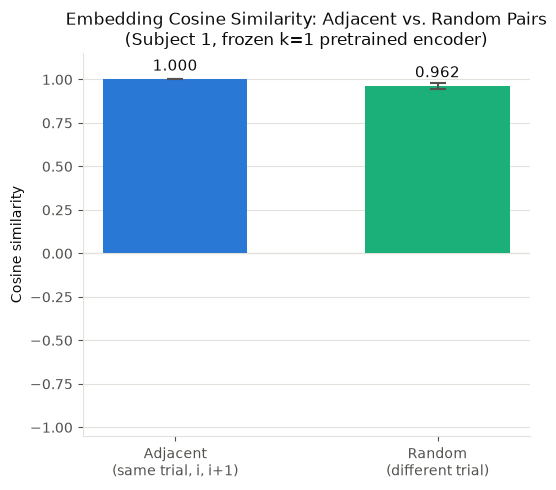

Saved: /workspaces/AH-PC/src/notebooks/diagnostic_cosine_similarity.png


In [7]:
fig, ax = plt.subplots(figsize=(5.5, 5))

labels = ["Adjacent\n(same trial, i, i+1)", "Random\n(different trial)"]
means = [adj_mean, rand_mean]
stds = [adj_std, rand_std]
colors = [COLOR_BLUE, COLOR_AQUA]

bars = ax.bar(labels, means, yerr=stds, capsize=6, width=0.55,
              color=colors, edgecolor="none", zorder=3,
              error_kw=dict(ecolor=COLOR_MUTED, elinewidth=1.5, capthick=1.5))

for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, m + 0.03, f"{m:.3f}",
            ha="center", va="bottom", fontsize=11, color=COLOR_TEXT)

ax.set_ylabel("Cosine similarity", color=COLOR_TEXT)
ax.set_title("Embedding Cosine Similarity: Adjacent vs. Random Pairs\n(Subject 1, frozen k=1 pretrained encoder)",
             color=COLOR_TEXT, fontsize=12)
ax.set_ylim(-1.05, 1.15)
ax.axhline(0, color=COLOR_GRID, linewidth=1, zorder=1)
ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(COLOR_GRID)
ax.tick_params(colors=COLOR_MUTED)

plt.tight_layout()
plt.savefig(COSINE_PLOT_PATH, dpi=150, facecolor="white")
plt.show()
print(f"Saved: {COSINE_PLOT_PATH}")


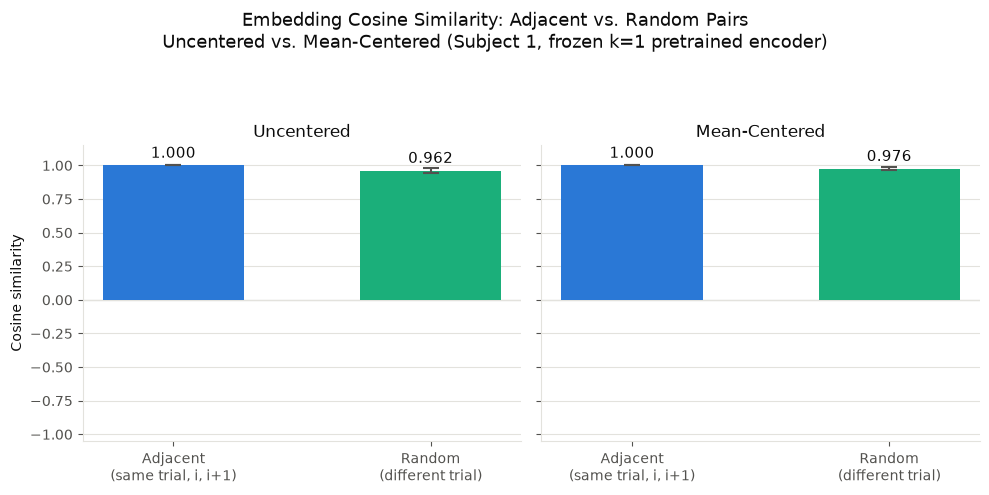

Saved: /workspaces/AH-PC/src/notebooks/diagnostic_cosine_similarity_centered.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

labels = ["Adjacent\n(same trial, i, i+1)", "Random\n(different trial)"]
colors = [COLOR_BLUE, COLOR_AQUA]

panels = [
    ("Uncentered", [adj_mean, rand_mean], [adj_std, rand_std]),
    ("Mean-Centered", [adj_mean_c, rand_mean_c], [adj_std_c, rand_std_c]),
]

for ax, (title, means, stds) in zip(axes, panels):
    bars = ax.bar(labels, means, yerr=stds, capsize=6, width=0.55,
                  color=colors, edgecolor="none", zorder=3,
                  error_kw=dict(ecolor=COLOR_MUTED, elinewidth=1.5, capthick=1.5))
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, m + 0.03, f"{m:.3f}",
                ha="center", va="bottom", fontsize=11, color=COLOR_TEXT)
    ax.set_title(title, color=COLOR_TEXT, fontsize=12)
    ax.set_ylim(-1.05, 1.15)
    ax.axhline(0, color=COLOR_GRID, linewidth=1, zorder=1)
    ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(COLOR_GRID)
    ax.tick_params(colors=COLOR_MUTED)

axes[0].set_ylabel("Cosine similarity", color=COLOR_TEXT)
fig.suptitle("Embedding Cosine Similarity: Adjacent vs. Random Pairs\n"
             "Uncentered vs. Mean-Centered (Subject 1, frozen k=1 pretrained encoder)",
             color=COLOR_TEXT, fontsize=13)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(COSINE_PLOT_CENTERED_PATH, dpi=150, facecolor="white")
plt.show()
print(f"Saved: {COSINE_PLOT_CENTERED_PATH}")


## Check 1c — Corrected Cosine-Similarity Mean-Centering

The mean-centered variant above (Check 1) subtracted a *within-Subject-1* global
mean segment and then **re-embedded** — and an earlier iteration subtracted each
segment's *own* mean, which is wrong: it removes each segment's scalar offset
individually and destroys the shared component we actually want to factor out.

This section fixes the centering and computes the cosine check **directly on the
raw `(62, 5)` segment vectors** (flattened to 310-d), not on encoder embeddings,
so the effect of the centering choice is visible without the encoder confounding
it. It reports all three variants side by side:

1. **Raw (uncentered)** — cosine on the segment vectors as-is.
2. **Wrong (per-segment mean)** — subtract each segment's own scalar mean before
   cosine (what we did before).
3. **Correct (global mean, 16 subj)** — subtract **one** global mean vector
   `global_mean = mean(all_segments, axis=0)` of shape `(62, 5)`, computed over
   **every segment of all 16 subjects**, before cosine.

Removing the true global (cross-subject) mean strips the shared "DC" component
that inflates cosine similarity uniformly, so any remaining adjacent-vs-random
gap reflects genuine temporal structure rather than a common offset. Adjacent /
random pairing follows Check 1 (adjacent = consecutive same-trial segments;
random = a segment from a different trial), with the same random draw reused
across all three variants. Saved to `diagnostic_cosine_corrected.png`.

In [9]:
COSINE_CORRECTED_PATH = os.path.join(NOTEBOOK_DIR, "diagnostic_cosine_corrected.png")
PROCESSED_DIR = "/workspaces/AH-PC/src/data/processed"

# --- ONE global mean vector across ALL segments of ALL 16 subjects -----------
all_subject_segments = []
for sid in range(1, 17):
    with open(os.path.join(PROCESSED_DIR, f"subject_{sid:02d}_pairs.pkl"), "rb") as f:
        subj_pairs = pickle.load(f)
    all_subject_segments.extend(np.asarray(p["anchor"], dtype=np.float32) for p in subj_pairs)

all_subject_segments = np.stack(all_subject_segments)   # (N_all, 62, 5)
global_mean = all_subject_segments.mean(axis=0)         # (62, 5) — the correct global mean
print(f"Global mean vector from {all_subject_segments.shape[0]} segments across 16 subjects, "
      f"shape = {global_mean.shape}")

# --- Three centering variants of every Subject-1 segment, flattened to 310-d --
# Cosine similarity is computed directly on the raw (62, 5) segment vectors
# (flattened), NOT on encoder embeddings. The three variants differ only in what
# is subtracted before flattening:
#   Raw                  : nothing (uncentered).
#   Per-segment mean     : each segment's own scalar mean  -> WRONG (what we did before).
#   Global mean (16 subj): the single global_mean vector   -> CORRECT.
def flat(seg):
    return np.asarray(seg, dtype=np.float32).ravel()

CENTERING_VARIANTS = [
    "Raw (uncentered)",
    "Wrong (per-segment mean)",
    "Correct (global mean, 16 subj)",
]

trial_vecs = {name: {} for name in CENTERING_VARIANTS}
for trial in trial_ids:
    segs = trial_segments[trial]
    trial_vecs["Raw (uncentered)"][trial]            = [flat(s) for s in segs]
    trial_vecs["Wrong (per-segment mean)"][trial]    = [flat(s - s.mean()) for s in segs]
    trial_vecs["Correct (global mean, 16 subj)"][trial] = [flat(s - global_mean) for s in segs]

# --- Adjacent (same trial i, i+1) vs random (different trial) cosine pairs -----
# Same random draw is reused across all three variants so they are directly
# comparable on identical pairs.
rng_corrected = np.random.default_rng(SEED)

corrected_adj = {name: [] for name in CENTERING_VARIANTS}
corrected_rnd = {name: [] for name in CENTERING_VARIANTS}

for trial in trial_ids:
    n = len(trial_segments[trial])
    other_trials = [t for t in trial_ids if t != trial]
    for i in range(n - 1):
        rand_trial = other_trials[rng_corrected.integers(len(other_trials))]
        rand_idx = rng_corrected.integers(len(trial_segments[rand_trial]))
        for name in CENTERING_VARIANTS:
            vecs = trial_vecs[name]
            corrected_adj[name].append(cosine(vecs[trial][i], vecs[trial][i + 1]))
            corrected_rnd[name].append(cosine(vecs[trial][i], vecs[rand_trial][rand_idx]))

for name in CENTERING_VARIANTS:
    corrected_adj[name] = np.array(corrected_adj[name])
    corrected_rnd[name] = np.array(corrected_rnd[name])

# --- Print all three ----------------------------------------------------------
for name in CENTERING_VARIANTS:
    a, r = corrected_adj[name], corrected_rnd[name]
    print()
    print(f"{name}:")
    print(f"  Adjacent (n={len(a)}): mean cosine = {a.mean():.4f}  (std = {a.std():.4f})")
    print(f"  Random   (n={len(r)}): mean cosine = {r.mean():.4f}  (std = {r.std():.4f})")
    print(f"  Gap (adjacent - random): {a.mean() - r.mean():+.4f}")


Global mean vector from 23408 segments across 16 subjects, shape = (62, 5)

Raw (uncentered):
  Adjacent (n=1418): mean cosine = 1.0000  (std = 0.0000)
  Random   (n=1418): mean cosine = 0.9930  (std = 0.0036)
  Gap (adjacent - random): +0.0070

Wrong (per-segment mean):
  Adjacent (n=1418): mean cosine = 1.0000  (std = 0.0000)
  Random   (n=1418): mean cosine = 0.9347  (std = 0.0343)
  Gap (adjacent - random): +0.0653

Correct (global mean, 16 subj):
  Adjacent (n=1418): mean cosine = 1.0000  (std = 0.0000)
  Random   (n=1418): mean cosine = 0.6415  (std = 0.1878)
  Gap (adjacent - random): +0.3585


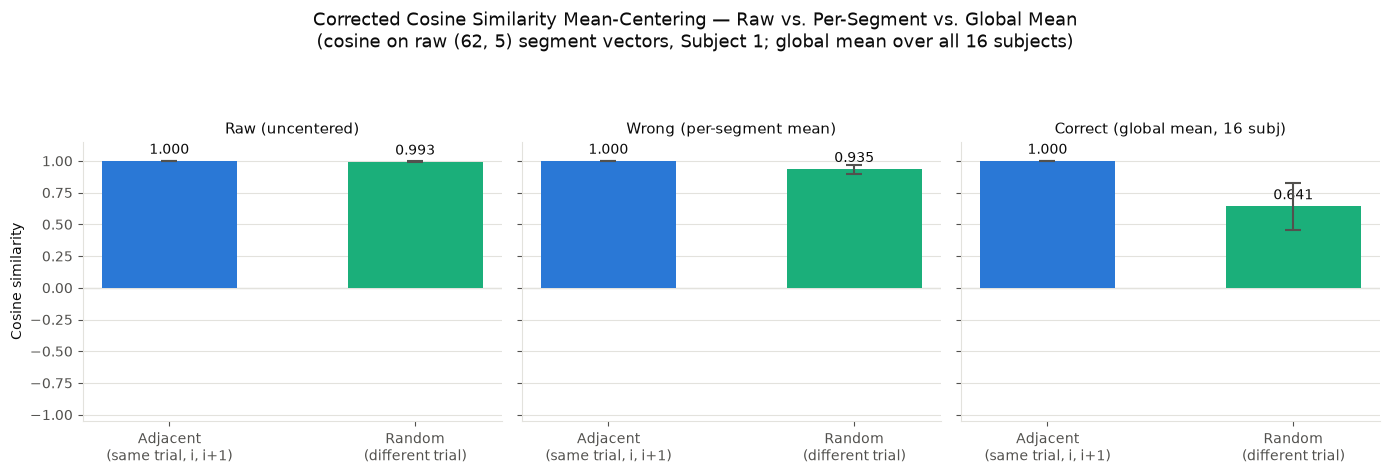

Saved: /workspaces/AH-PC/src/notebooks/diagnostic_cosine_corrected.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), sharey=True)

labels = ["Adjacent\n(same trial, i, i+1)", "Random\n(different trial)"]
colors = [COLOR_BLUE, COLOR_AQUA]

for ax, name in zip(axes, CENTERING_VARIANTS):
    a, r = corrected_adj[name], corrected_rnd[name]
    means = [a.mean(), r.mean()]
    stds = [a.std(), r.std()]
    bars = ax.bar(labels, means, yerr=stds, capsize=6, width=0.55,
                  color=colors, edgecolor="none", zorder=3,
                  error_kw=dict(ecolor=COLOR_MUTED, elinewidth=1.5, capthick=1.5))
    for bar, m in zip(bars, means):
        va = "bottom" if m >= 0 else "top"
        offset = 0.03 if m >= 0 else -0.03
        ax.text(bar.get_x() + bar.get_width() / 2, m + offset, f"{m:.3f}",
                ha="center", va=va, fontsize=10, color=COLOR_TEXT)
    ax.set_title(name, color=COLOR_TEXT, fontsize=11)
    ax.set_ylim(-1.05, 1.15)
    ax.axhline(0, color=COLOR_GRID, linewidth=1, zorder=1)
    ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(COLOR_GRID)
    ax.tick_params(colors=COLOR_MUTED)

axes[0].set_ylabel("Cosine similarity", color=COLOR_TEXT)
fig.suptitle("Corrected Cosine Similarity Mean-Centering — Raw vs. Per-Segment vs. Global Mean\n"
             "(cosine on raw (62, 5) segment vectors, Subject 1; global mean over all 16 subjects)",
             color=COLOR_TEXT, fontsize=13)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(COSINE_CORRECTED_PATH, dpi=150, facecolor="white")
plt.show()
print(f"Saved: {COSINE_CORRECTED_PATH}")


## Check 2 — Linear Probe MSE vs. k (k = 1 .. 25)

**What this measures:** for each offset `k`, we collect every valid
`(z_t, z_{t+k})` embedding pair within a trial (segment `i` and segment `i+k`,
`i+k` still inside the same trial), split 80/20 into train/test, and fit a single
`Linear(256, 256)` layer with MSE loss (Adam, `lr=1e-3`, 10 epochs) to predict
`z_{t+k}` from `z_t`. The **final test-set MSE** at each `k` is recorded.

**What the result means:** this is a direct measure of how much of the future
embedding is linearly recoverable from the current one, as a function of horizon.
An MSE that rises with `k` says predictability decays with distance — expected,
and informative for how far a "wider horizons" pretraining objective could
reasonably be pushed before the target is essentially unpredictable from a linear
readout of the present.

In [11]:
def build_k_pairs(k):
    """All (z_t, z_{t+k}) pairs across every trial for this subject."""
    X, Y = [], []
    for trial in trial_ids:
        embs = trial_embeddings[trial]
        n = embs.shape[0]
        for i in range(n - k):
            X.append(embs[i])
            Y.append(embs[i + k])
    return np.stack(X), np.stack(Y)


def fit_linear_probe(X, Y, epochs=10, lr=1e-3, batch_size=64, seed=SEED):
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=seed
    )

    X_train_t = torch.from_numpy(X_train).float().to(DEVICE)
    Y_train_t = torch.from_numpy(Y_train).float().to(DEVICE)
    X_test_t = torch.from_numpy(X_test).float().to(DEVICE)
    Y_test_t = torch.from_numpy(Y_test).float().to(DEVICE)

    torch.manual_seed(seed)
    probe = nn.Linear(LATENT_DIM, LATENT_DIM).to(DEVICE)
    optimizer = torch.optim.Adam(probe.parameters(), lr=lr)
    criterion = nn.MSELoss()

    n_train = X_train_t.shape[0]
    for epoch in range(epochs):
        perm = torch.randperm(n_train)
        for start in range(0, n_train, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = X_train_t[idx], Y_train_t[idx]
            optimizer.zero_grad()
            pred = probe(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

    probe.eval()
    with torch.no_grad():
        test_pred = probe(X_test_t)
        test_mse = criterion(test_pred, Y_test_t).item()
    return test_mse, len(X_train), len(X_test)


K_VALUES = list(range(1, 26))
mse_by_k = []

print(f"{'k':>3s}  {'n_pairs':>8s}  {'n_train':>8s}  {'n_test':>7s}  {'test_mse':>10s}")
for k in K_VALUES:
    X, Y = build_k_pairs(k)
    test_mse, n_train, n_test = fit_linear_probe(X, Y)
    mse_by_k.append(test_mse)
    print(f"{k:>3d}  {len(X):>8d}  {n_train:>8d}  {n_test:>7d}  {test_mse:>10.4f}")

mse_by_k = np.array(mse_by_k)


  k   n_pairs   n_train   n_test    test_mse
  1      1418      1134      284      0.0065
  2      1373      1098      275      0.0068
  3      1328      1062      266      0.0069
  4      1283      1026      257      0.0075
  5      1238       990      248      0.0072
  6      1194       955      239      0.0073
  7      1151       920      231      0.0074
  8      1108       886      222      0.0080
  9      1067       853      214      0.0077
 10      1027       821      206      0.0084
 11       989       791      198      0.0084
 12       952       761      191      0.0091
 13       915       732      183      0.0093
 14       879       703      176      0.0097
 15       844       675      169      0.0102
 16       810       648      162      0.0101
 17       778       622      156      0.0107
 18       746       596      150      0.0104
 19       714       571      143      0.0113
 20       682       545      137      0.0116
 21       650       520      130      0.0117
 22       

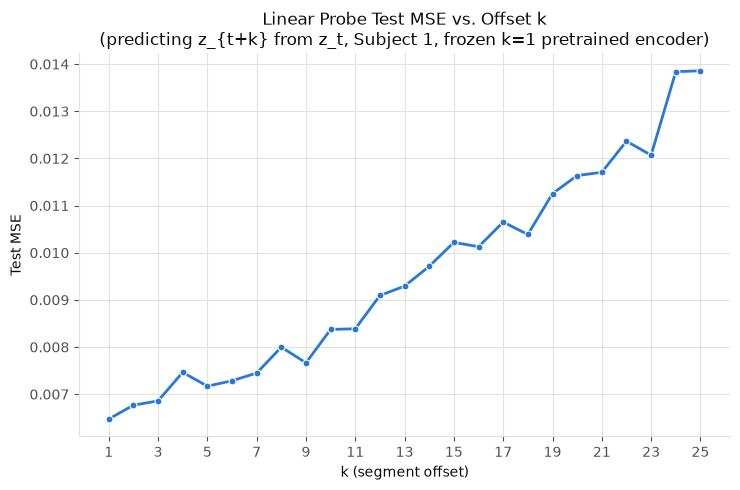

Saved: /workspaces/AH-PC/src/notebooks/diagnostic_linear_probe_mse.png


In [12]:
fig, ax = plt.subplots(figsize=(7.5, 5))

ax.plot(K_VALUES, mse_by_k, color=COLOR_BLUE, linewidth=2, marker="o",
        markersize=5, markerfacecolor=COLOR_BLUE, markeredgecolor="white",
        markeredgewidth=0.8, zorder=3)

ax.set_xlabel("k (segment offset)", color=COLOR_TEXT)
ax.set_ylabel("Test MSE", color=COLOR_TEXT)
ax.set_title("Linear Probe Test MSE vs. Offset k\n(predicting z_{t+k} from z_t, Subject 1, frozen k=1 pretrained encoder)",
             color=COLOR_TEXT, fontsize=12)
ax.set_xticks(K_VALUES[::2])
ax.grid(color=COLOR_GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(COLOR_GRID)
ax.tick_params(colors=COLOR_MUTED)

plt.tight_layout()
plt.savefig(MSE_PLOT_PATH, dpi=150, facecolor="white")
plt.show()
print(f"Saved: {MSE_PLOT_PATH}")


## Summary

In [13]:
print("=" * 70)
print("CHECK 1 — Cosine similarity")
print("=" * 70)
print(f"  Adjacent (same trial, i vs i+1): mean={adj_mean:.4f}, std={adj_std:.4f}, n={len(adjacent_sims)}")
print(f"  Random (different trial):        mean={rand_mean:.4f}, std={rand_std:.4f}, n={len(random_sims)}")
print(f"  Gap (adjacent - random):         {adj_mean - rand_mean:+.4f}")
if adj_mean - rand_mean > 0.05:
    print("  -> Adjacent pairs are clearly MORE similar than random cross-trial pairs:")
    print("     the encoder's embedding space reflects real temporal/trial structure,")
    print("     not just noise.")
elif adj_mean - rand_mean > 0:
    print("  -> Adjacent pairs are only slightly more similar than random pairs:")
    print("     weak evidence of temporal structure in the embedding space.")
else:
    print("  -> Adjacent pairs are NOT more similar than random pairs:")
    print("     the embedding space does not appear to encode temporal continuity —")
    print("     worth investigating before pursuing wider horizons.")

print()
print("=" * 70)
print("CHECK 2 — Linear probe MSE vs k")
print("=" * 70)
for k, mse in zip(K_VALUES, mse_by_k):
    print(f"  k={k:>2d}: test MSE = {mse:.4f}")

slope = np.polyfit(K_VALUES, mse_by_k, 1)[0]
print(f"\n  MSE at k=1:  {mse_by_k[0]:.4f}")
print(f"  MSE at k=25: {mse_by_k[-1]:.4f}")
print(f"  Linear trend (slope of MSE vs k): {slope:+.5f} per step")
if slope > 0:
    print("  -> MSE increases with k: predictability decays as the horizon grows,")
    print("     as expected. This bounds how far a 'wider horizons' objective can")
    print("     usefully be pushed with a purely linear readout.")
else:
    print("  -> MSE does NOT increase with k: the embedding is roughly as linearly")
    print("     predictable at long horizons as at short ones — worth double-checking")
    print("     before assuming wider horizons are harder to learn.")


CHECK 1 — Cosine similarity
  Adjacent (same trial, i vs i+1): mean=1.0000, std=0.0000, n=1418
  Random (different trial):        mean=0.9618, std=0.0195, n=1418
  Gap (adjacent - random):         +0.0382
  -> Adjacent pairs are only slightly more similar than random pairs:
     weak evidence of temporal structure in the embedding space.

CHECK 2 — Linear probe MSE vs k
  k= 1: test MSE = 0.0065
  k= 2: test MSE = 0.0068
  k= 3: test MSE = 0.0069
  k= 4: test MSE = 0.0075
  k= 5: test MSE = 0.0072
  k= 6: test MSE = 0.0073
  k= 7: test MSE = 0.0074
  k= 8: test MSE = 0.0080
  k= 9: test MSE = 0.0077
  k=10: test MSE = 0.0084
  k=11: test MSE = 0.0084
  k=12: test MSE = 0.0091
  k=13: test MSE = 0.0093
  k=14: test MSE = 0.0097
  k=15: test MSE = 0.0102
  k=16: test MSE = 0.0101
  k=17: test MSE = 0.0107
  k=18: test MSE = 0.0104
  k=19: test MSE = 0.0113
  k=20: test MSE = 0.0116
  k=21: test MSE = 0.0117
  k=22: test MSE = 0.0124
  k=23: test MSE = 0.0121
  k=24: test MSE = 0.0138
  k

### Takeaways for the supervisor

- **Check 1** tells us whether the frozen k=1-pretrained encoder's embedding space
  encodes anything about temporal continuity within a trial, versus being
  effectively unstructured noise from the perspective of cosine similarity.
- **Check 2** tells us how quickly that structure decays as the prediction horizon
  grows, using the simplest possible readout (a single linear layer). Both numbers
  above are computed fresh from Subject 1's data and the current
  `ahpc_k1_pretrained_best.pt` checkpoint — see the printed values and the two
  saved plots (`diagnostic_cosine_similarity.png`,
  `diagnostic_linear_probe_mse.png`) for the full picture before deciding whether
  to invest in wider-horizon pretraining.